In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [44]:
df = pd.read_csv("heart_data.csv")
print(df.shape)
df.head()

(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [46]:
print(df.isnull().sum().sum())
print(df['target'].value_counts())
print(f"balance: {df['target'].value_counts()[1]/df['target'].value_counts()[0]:.2f}:1")

0
target
1    526
0    499
Name: count, dtype: int64
balance: 1.05:1


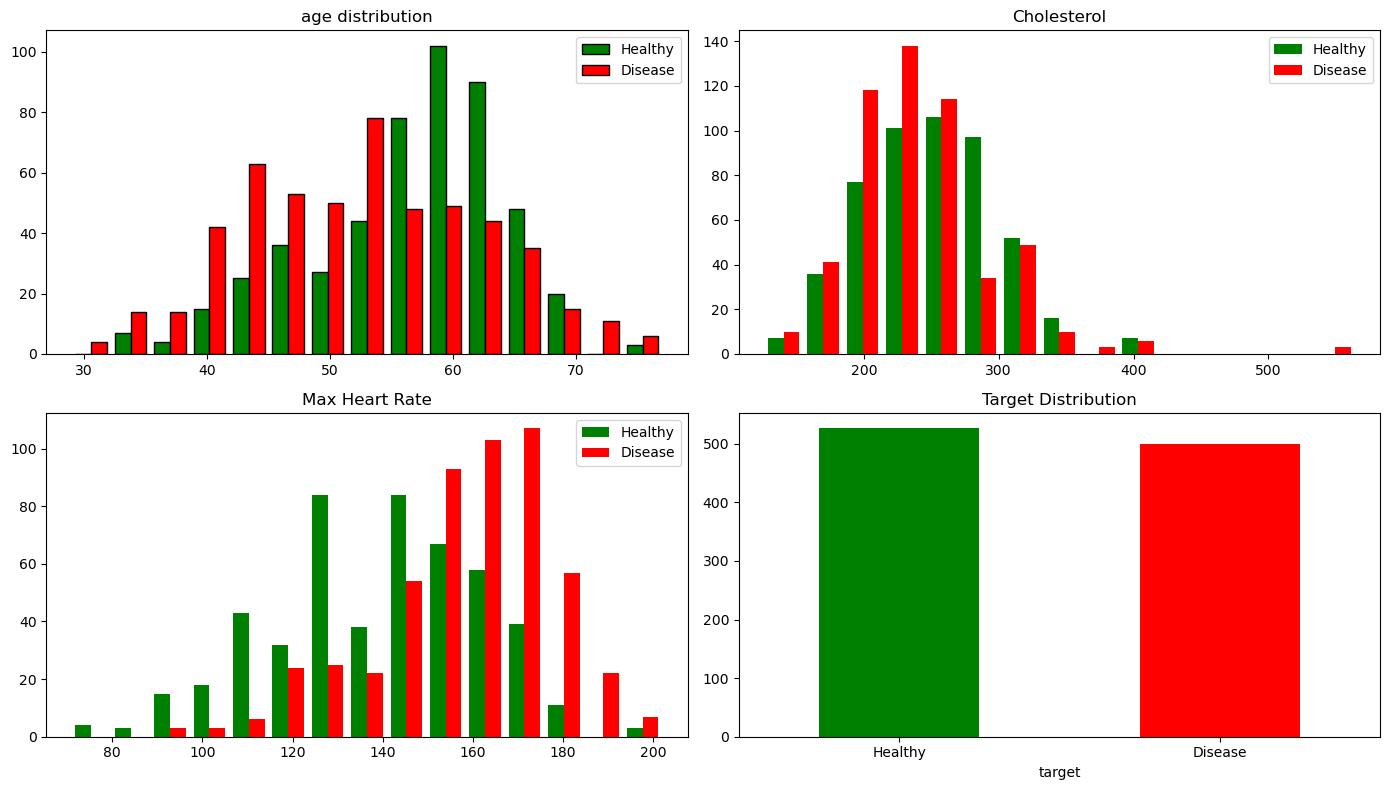

In [47]:
fig,axes = plt.subplots(2,2,figsize=(14,8))
axes[0, 0].hist(
    [df[df['target'] == 0]["age"], df[df['target'] == 1]["age"]],
    label=["Healthy", "Disease"],
    bins=15,
    color=['green', 'red'],
    edgecolor='black'
)
axes[0,0].set_title("age distribution")
axes[0,0].legend()

axes[0,1].hist(
    [df[df['target']==0]['chol'], df[df['target']==1]['chol']],
    label=['Healthy', 'Disease'],
    bins=15,
    color=['green', 'red']
)
axes[0,1].set_title('Cholesterol')
axes[0,1].legend()

axes[1,0].hist(
    [df[df['target']==0]['thalach'], df[df['target']==1]['thalach']],
    label=['Healthy', 'Disease'],
    bins=15,
    color=['green', 'red']
)
axes[1,0].set_title('Max Heart Rate')
axes[1,0].legend()

df['target'].value_counts().plot(
    kind='bar',
    ax=axes[1,1],
    color=['green', 'red']
)
axes[1,1].set_title('Target Distribution')
axes[1,1].set_xticklabels(['Healthy', 'Disease'], rotation=0)

plt.tight_layout()
plt.show()

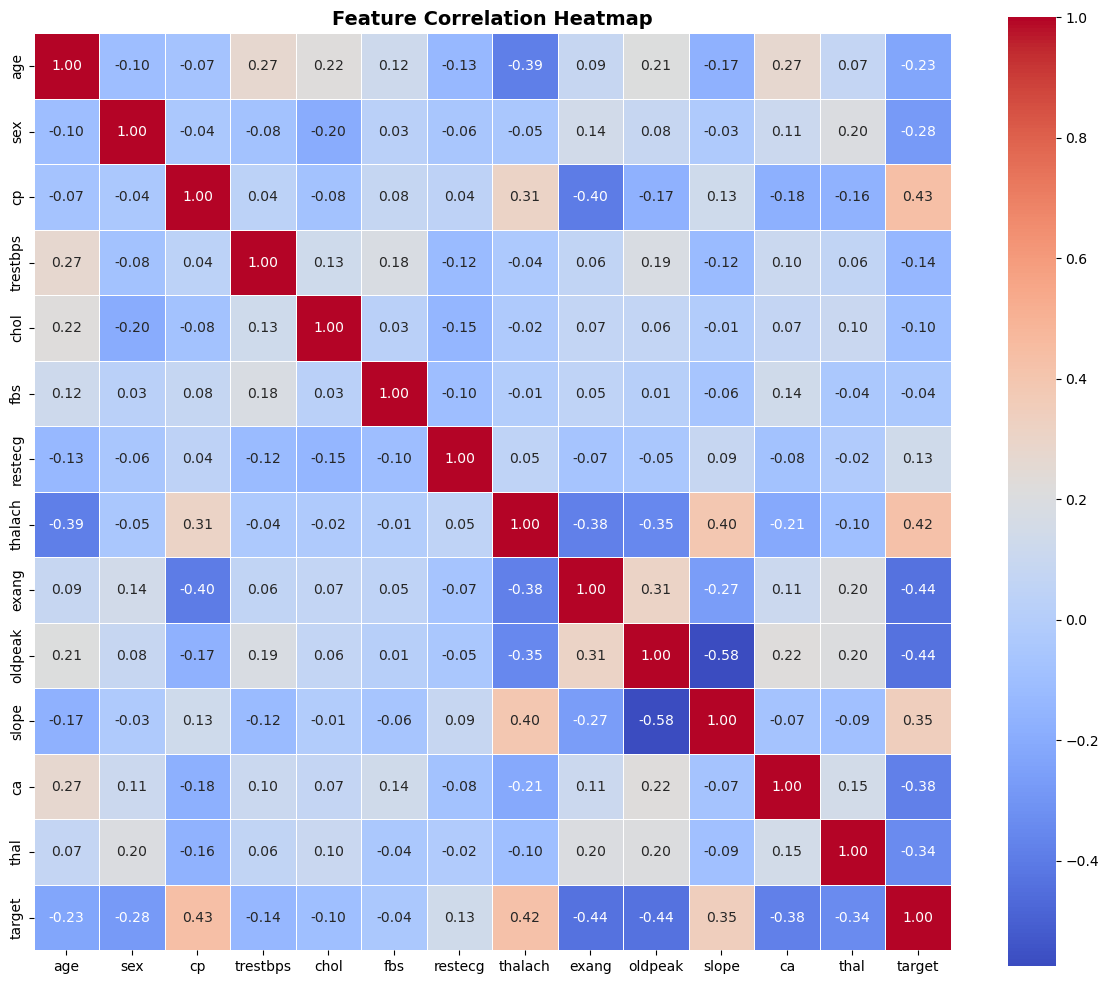

In [48]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    df.corr(),
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot = True,
    square=True
)

plt.title(
    'Feature Correlation Heatmap',
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [49]:
x = df.drop(columns = 'target')
y = df['target']

print(x.shape)
print(y.shape)

(1025, 13)
(1025,)


In [50]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,stratify=y,random_state=42)
print(x_train.shape[0])
print(x_test.shape[0])

820
205


In [52]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

joblib.dump(scaler, "heart_scaler.pkl")

['heart_scaler.pkl']

In [55]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

score = cross_val_score(
    model,
    x_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(f"CV Accuracy: {score.mean():.4f} (+/- {score.std():.4f})")

CV Accuracy: 0.8439 (+/- 0.0240)


In [57]:
model.fit(x_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [62]:
y_train_pred = model.predict(x_train_scaled)
y_test_pred  = model.predict(x_test_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print(f"Train Accuracy: {train_acc}")
print(f"Test  Accuracy: {test_acc}")

print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Healthy", "Disease"]
))

Train Accuracy: 0.8463414634146341
Test  Accuracy: 0.8097560975609757
              precision    recall  f1-score   support

     Healthy       0.89      0.70      0.78       100
     Disease       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



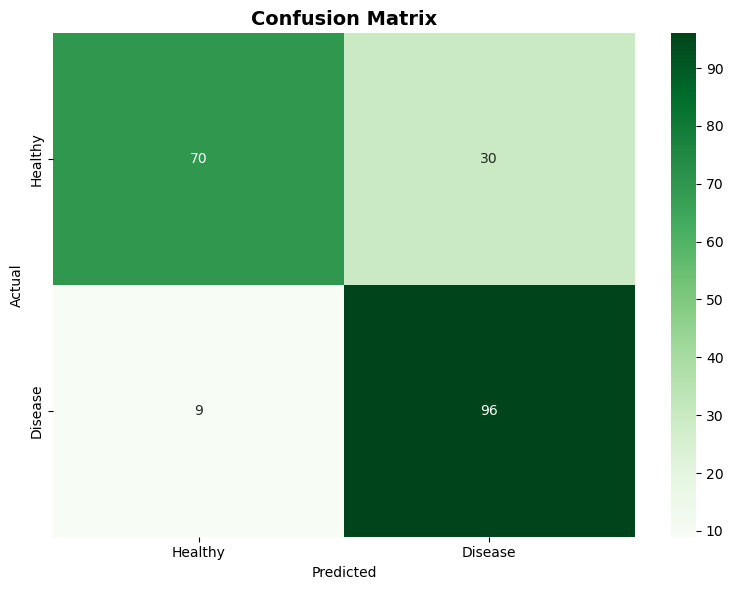

In [64]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Greens",
    xticklabels=["Healthy", "Disease"],
    yticklabels=["Healthy", "Disease"]
)

plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [66]:
model_data = {
    "model":model,
    "feature_names":x.columns.tolist()
}
joblib.dump(model_data,"heart_disease_model.pkl")

['heart_disease_model.pkl']